©2026. For information, contact Deloitte Tohmatsu Group.

# 📝 演習概要

この演習では、MNISTデータセット（手書き数字画像）を用いて多層パーセプトロン（DNN）をNumPyでスクラッチ実装します。ミニバッチ版交差エントロピー誤差、活性化関数の定義、ネットワーク構築、学習ループの実装を通じて、ニューラルネットワークの基本動作を理解します。

# 事前準備

[JDLAが策定しているバージョン](https://www.jdla.org/certificate/engineer/)に合わせるために、以下のセルの実行をお願いします．

（#コメントアウト されているものは必要ありません）

また実行完了後に「ランタイムの再起動」をして下さい．

（以下のセルの実行は、最初にしていただければ、以降必要ありません．）


In [ ]:
%%capture
!pip uninstall matplotlib -y
!pip install matplotlib==3.9.4

# !pip uninstall opencv-python -y
# !pip install opencv-python==4.11.0.86

# !pip uninstall torch -y
# !pip install torch==2.7.0

# !pip uninstall torchvision -y
# !pip install torchvision==0.22.0

# MNISTデータセットの学習

In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# MNISTデータのロードと訓練データ、テストデータの分割
def load_mnist():
    # MNISTデータセットを取得
    mnist = fetch_openml('MNIST_784', version=1, data_home="MNIST_data/")

    # shuffleでデータとラベルを同じ並びでシャッフル
    mnist_X, mnist_y = shuffle(
        mnist.data.astype('float32'),   # 画素値をfloat32に
        mnist.target.astype('int32'),   # ラベルをint32に
        random_state=42
    )

    # 画素値を0〜1に正規化（元は0〜255の輝度）
    mnist_X = mnist_X.values / 255.0

    # one-hot表現に変換
    mnist_y = np.eye(10)[mnist_y]

    return train_test_split(mnist_X, mnist_y,
                test_size=0.2,
                random_state=42)

In [ ]:
# それぞれのデータの形式を出力
x_train, x_test, y_train, y_test = load_mnist()
print('学習データ ', x_train.shape)   # (N_train, 784)
print('正解ラベル ', y_train.shape)   # (N_train, 10)
print('テストデータ ', x_test.shape)  # (N_test, 784)
print('正解ラベル ', y_test.shape)    # (N_test, 10)

学習データ  (56000, 784)
正解ラベル  (56000, 10)
テストデータ  (14000, 784)
正解ラベル  (14000, 10)


<Figure size 640x480 with 0 Axes>

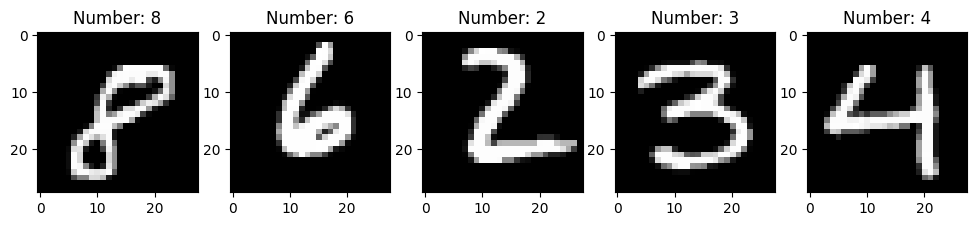

In [ ]:
# いくつか画像を可視化（one-hotラベルをargmaxで数字に戻してタイトルに表示）
plt.subplots_adjust(wspace=0.4, hspace=0.6)
plt.figure(figsize=(12, 6))
for num in range(5):
  plt.subplot(1, 5, num+1)
  plt.imshow(x_train[num].reshape(28, 28), cmap='gray')
  plt.title('Number: {}'.format(np.argmax(y_train[num])))
plt.show()

## ミニバッチ版交差エントロピー誤差

In [ ]:
# 交差エントロピー誤差
def cross_entropy_error(y, t):
    return np.sum(-t*np.log(y)-(1-t)*np.log(1-y))

In [ ]:
# # バッチ版交差エントロピー誤差
# def cross_entropy_error(y, t):
#     delta = 1e-7  # log(0)防止のための微小値
#     # ベクトルだけ渡されたとき (shapeが1次元) への対応
#     if y.ndim == 1:
#         t = t.reshape(1, t.size)
#         y = y.reshape(1, y.size)

#     batch_size = y.shape[0]  # バッチ数
#     print(np.arange(batch_size))
#     t = t.astype(int)
#     print(t)
#     print(y[np.arange(batch_size), t])
#     # クロスエントロピー (負の対数尤度)
#     return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

## 活性化関数の定義

In [ ]:
# シグモイド関数
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def deriv_sigmoid(x):
    return (1 - sigmoid(x)) * sigmoid(x)

In [ ]:
# Softmax関数
def softmax(x):
    exp_x = np.exp(x)
    return exp_x/np.sum(exp_x, axis=1, keepdims=True)

## ニューラルネットワークの定義

In [ ]:
# 2層のニューラルネットワーク
class TwoLayerNet:

    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):

        # パラメータ(重みとバイアス)をdictにまとめて保持
        # W1: (入力次元, 隠れ層次元)
        # b1: (隠れ層次元,)
        # W2: (隠れ層次元, 出力次元)
        # b2: (出力次元,)

        # 重みの初期化
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    def predict(self, x):
        """
        順伝播処理:
          x   -> u1 -> z1 -> u2 -> y
          u1 = xW1 + b1
          z1 = sigmoid(u1)
          u2 = z1W2 + b2
          y  = softmax(u2)
        戻り値: 各クラスの確率 (batch, output_size)
        """
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']

        # 1層目: Affine + Sigmoid
        u1 = np.dot(x, W1) + b1      # (batch, hidden_size)
        z1 = sigmoid(u1)             # (batch, hidden_size)

        # 2層目: Affine + Softmax
        u2 = np.dot(z1, W2) + b2     # (batch, output_size)
        y = softmax(u2)              # (batch, output_size) 10クラスの確率

        return y

    # x:入力データ, t:教師データ
    def loss(self, x, t):
        y = self.predict(x)

        return cross_entropy_error(y, t)

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)  # 予測したクラスID
        t = np.argmax(t, axis=1)  # 正解クラスID

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    # 数値計算で勾配を求めると計算時間がかかるため、逆伝播法をはじめから実装
    def gradient(self, x, t):
        """
        誤差逆伝播で勾配(∂L/∂W1 など)を計算する。

        戻り値:
          grads: dict形式
            grads['W1'], grads['b1'], grads['W2'], grads['b2']
        """
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
        grads = {}

        batch_num = x.shape[0]  # バッチサイズ

        # ---- forward (順伝播) ----
        u1 = np.dot(x, W1) + b1     # (batch, hidden)
        z1 = sigmoid(u1)            # (batch, hidden)
        u2 = np.dot(z1, W2) + b2    # (batch, output)
        y = softmax(u2)             # (batch, output)

        # ---- backward (逆伝播) ----
        # 出力層のソフトマックス + クロスエントロピーの微分
        # dy = (y - t) / バッチサイズ
        dy = (y - t) / batch_num  # (batch, output)

        # W2, b2 の勾配
        grads['W2'] = np.dot(z1.T, dy)          # (hidden, batch) x (batch, output) -> (hidden, output)
        grads['b2'] = np.sum(dy, axis=0)        # (output,)

        # 隠れ層側の勾配
        du1 = np.dot(dy, W2.T)                  # (batch, hidden)
        dz1 = deriv_sigmoid(u1) * du1           # シグモイドの勾配を掛ける

        # W1, b1 の勾配
        grads['W1'] = np.dot(x.T, dz1)          # (input, batch) x (batch, hidden) -> (input, hidden)
        grads['b1'] = np.sum(dz1, axis=0)       # (hidden,)

        return grads

## ニューラルネットワークの作成

In [ ]:
network = TwoLayerNet(input_size=784, hidden_size=100, output_size=10)

In [ ]:
# ハイパーパラメーター
epoch = 100                     # エポック数
train_size = x_train.shape[0]   # 訓練データの数
mini_batch = 100                # ミニバッチ数
lr = 0.01                       # 学習率

In [ ]:
train_loss_list = []  # 各エポックの損失を記録
train_acc_list = []   # 各エポックの訓練精度
test_acc_list = []    # 各エポックのテスト精度

# 1エポックあたりに何回パラメータ更新するか
iter_per_epoch = int(max(train_size / mini_batch, 1))

In [ ]:
for i in range(epoch):
    # ロスの初期化
    loss = 0
    # イテレーションの開始
    for j in range(iter_per_epoch):
        # ミニバッチの取得
        batch_mask = np.random.choice(train_size, mini_batch)
        x_batch = x_train[batch_mask]
        y_batch = y_train[batch_mask]

        # 誤差逆伝播法によって勾配を求める
        grad = network.gradient(x_batch, y_batch)

        # パラメータの更新
        for key in ('W1', 'b1', 'W2', 'b2'):
            network.params[key] -= lr * grad[key]

        # 学習経過の記録
        loss += network.loss(x_batch, y_batch)

    # 1エポックごとにロスを追加
    train_loss_list.append(loss)
    # 1エポックごとに認識精度を計算
    train_acc = network.accuracy(x_train, y_train)
    test_acc = network.accuracy(x_test, y_test)
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

    # 学習の進み具合を表示
    print(str(i+1) + "epoch: train acc, test acc, loss | " + str(train_acc) + ", " + str(test_acc) + ", " + str(loss))

1epoch: train acc, test acc, loss | 0.11210714285714286, 0.11421428571428571, 181562.67663326376
2epoch: train acc, test acc, loss | 0.13617857142857143, 0.13835714285714285, 180396.21895240466
3epoch: train acc, test acc, loss | 0.4488035714285714, 0.4529285714285714, 176809.4351292556
4epoch: train acc, test acc, loss | 0.5505357142857142, 0.553, 166224.1282422483
5epoch: train acc, test acc, loss | 0.6102142857142857, 0.6147142857142858, 146846.39751651467
6epoch: train acc, test acc, loss | 0.6546607142857143, 0.6542857142857142, 125132.94114102783
7epoch: train acc, test acc, loss | 0.7156071428571429, 0.7121428571428572, 107753.10704041336
8epoch: train acc, test acc, loss | 0.7625357142857143, 0.7610714285714286, 94047.86332464947
9epoch: train acc, test acc, loss | 0.7911428571428571, 0.7897857142857143, 83871.41514602194
10epoch: train acc, test acc, loss | 0.8118571428571428, 0.809, 76302.82120085873
11epoch: train acc, test acc, loss | 0.8237857142857142, 0.8222142857142857,

In [ ]:
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))

plt.plot(x, train_acc_list, label='train acc')           # 訓練精度
plt.plot(x, test_acc_list, label='test acc', linestyle='--')  # テスト精度(破線)

plt.xlabel("epoches")   # 横軸: エポック数
plt.ylabel('accuracy')  # 縦軸: 精度(0.0〜1.0)
plt.ylim(0, 1.0)        # y軸の範囲を0〜1に固定
plt.legend(loc='lower right')
plt.show()

## 🔧 実践問題1：隠れ層のサイズと学習率を変えて精度を改善する

上のコードでは `hidden_size=100`, `lr=0.01`, `epoch=100` で学習しました。
しかし、隠れ層のサイズや学習率の組み合わせによって最終精度や収束速度は大きく変わります。

| パラメータ | 大きくすると | 小さくすると |
|:---|:---|:---|
| `hidden_size` | 表現力が上がるが、過学習しやすくなり計算も遅くなる | 学習が速いが、複雑なパターンを捉えきれない |
| `lr`（学習率） | 速く収束するが、最適値を飛び越えて発散する危険がある | 安定するが、収束が遅く局所解に捕まりやすい |
| `epoch` | より長く学習できるが、過学習のリスクが増す | 学習不足になる可能性がある |

一般に、隠れ層を大きくしたときは学習率を少し下げると安定しやすくなります。

---


**問題：** 以下のコードの `______` を自分で決めて、上の結果と異なる構成で学習を行い、精度の変化を比較してください。

> **注意：** 隠れ層を大きくしすぎると学習にかなり時間がかかります。50〜300の範囲で試すのがおすすめです。


In [ ]:
# 隠れ層のサイズと学習率を変えて実験する

# TODO: hidden_size, lr, epoch を自分で設定してください
network2 = TwoLayerNet(input_size=784, hidden_size=______, output_size=10)

epoch2 = ______
lr2 = ______
mini_batch2 = 100
train_size2 = x_train.shape[0]
iter_per_epoch2 = int(max(train_size2 / mini_batch2, 1))

train_loss2 = []
train_acc2 = []
test_acc2 = []

for i in range(epoch2):
    loss = 0
    for j in range(iter_per_epoch2):
        batch_mask = np.random.choice(train_size2, mini_batch2)
        x_batch = x_train[batch_mask]
        y_batch = y_train[batch_mask]

        grad = network2.gradient(x_batch, y_batch)
        for key in ('W1', 'b1', 'W2', 'b2'):
            network2.params[key] -= lr2 * grad[key]
        loss += network2.loss(x_batch, y_batch)

    train_loss2.append(loss)
    train_acc2.append(network2.accuracy(x_train, y_train))
    test_acc2.append(network2.accuracy(x_test, y_test))

    if (i+1) % 10 == 0:
        print(f'{i+1}epoch: train={train_acc2[-1]:.4f}, test={test_acc2[-1]:.4f}, loss={loss:.2f}')

# 元の結果と比較してプロット
plt.plot(train_acc_list, label='original train')
plt.plot(test_acc_list, label='original test', linestyle='--')
plt.plot(train_acc2, label='new train')
plt.plot(test_acc2, label='new test', linestyle='--')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.ylim(0, 1.0)
plt.legend(); plt.title('Hidden size & LR comparison'); plt.show()


<details><summary>解答例</summary>

```python
# 例1: 隠れ層を大きく（200）、学習率をやや下げる
network2 = TwoLayerNet(input_size=784, hidden_size=200, output_size=10)
epoch2 = 100
lr2 = 0.005

# 例2: 隠れ層を小さく（50）、学習率をやや上げる
network2 = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)
epoch2 = 150
lr2 = 0.02
```

- `hidden_size=200` にすると表現力が上がり最終精度が改善する傾向がありますが、学習率が大きすぎると不安定になります。`lr=0.005` 程度に下げるとバランスが取れます
- `hidden_size=50` にすると計算は速くなりますが、100次元のときより精度がやや下がることが多いです。学習率を少し上げると収束が速まります
- 元のモデル（hidden=100, lr=0.01）と学習曲線を比較し、train/testの差（＝過学習の度合い）にも注目してください
- 唯一の正解はなく、実際に複数パターンを試して比較する経験が重要です
</details>


## 🔧 実践問題2：重みの初期化方法を変えて学習の安定性を比較する

上のコードでは重みを `weight_init_std=0.01` の正規分布で初期化しています。
しかし、初期化の方法によって学習の安定性や収束速度が大きく変わります。

| 初期化手法 | 標準偏差の計算式 | 適した活性化関数 |
|:---|:---|:---|
| 固定値（現在） | `0.01` | — |
| Xavier初期化 | `sqrt(1 / 前の層のニューロン数)` | sigmoid, tanh |
| He初期化 | `sqrt(2 / 前の層のニューロン数)` | ReLU |

Xavier初期化はシグモイド関数と相性が良く、各層の出力の分散を一定に保つことで**勾配消失を緩和**できます。

---

**問題：** 以下のコードの `______` を埋めて、Xavier初期化を適用した `TwoLayerNet` を手動で作成し、元の結果と精度を比較してください。

<br/>

<details>
<summary>💡 <b>ヒント（クリックして表示）</b></summary>

<blockquote>
Xavier初期化のW1は形状 <code>(784, hidden_size)</code> で、標準偏差は <code>np.sqrt(1.0 / 前の層の次元数)</code> です。W2も同様です。
</blockquote>

</details>

<br/>


In [ ]:
# Xavier初期化で重みを設定して学習する

hidden_size = 100

network3 = TwoLayerNet(input_size=784, hidden_size=hidden_size, output_size=10)

# Xavier初期化で重みを上書き
network3.params['W1'] = np.random.randn(784, hidden_size) * np.sqrt(______ / ______)
network3.params['W2'] = np.random.randn(______, 10) * np.sqrt(1.0 / ______)

# 学習（元と同じハイパーパラメータで比較）
epoch3 = 100
lr3 = 0.01
iter3 = int(max(x_train.shape[0] / 100, 1))

train_acc3, test_acc3 = [], []
for i in range(epoch3):
    for j in range(iter3):
        mask = np.random.choice(x_train.shape[0], 100)
        grad = network3.gradient(x_train[mask], y_train[mask])
        for key in ('W1', 'b1', 'W2', 'b2'):
            network3.params[key] -= lr3 * grad[key]

    train_acc3.append(network3.accuracy(x_train, y_train))
    test_acc3.append(network3.accuracy(x_test, y_test))
    if (i+1) % 20 == 0:
        print(f'{i+1}epoch: train={train_acc3[-1]:.4f}, test={test_acc3[-1]:.4f}')

# 比較プロット
plt.plot(train_acc_list, label='std=0.01 train')
plt.plot(test_acc_list, label='std=0.01 test', linestyle='--')
plt.plot(train_acc3, label='Xavier train')
plt.plot(test_acc3, label='Xavier test', linestyle='--')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.ylim(0, 1.0)
plt.legend(); plt.title('Weight initialization comparison'); plt.show()


<details><summary>解答例</summary>

```python
# Xavier初期化で重みを上書き
network3.params['W1'] = np.random.randn(784, hidden_size) * np.sqrt(1.0 / 784)
network3.params['W2'] = np.random.randn(hidden_size, 10) * np.sqrt(1.0 / hidden_size)
```

- Xavier初期化では `W1` の標準偏差を `sqrt(1/784)` ≈ 0.036 にします。`weight_init_std=0.01` より大きいため、初期の勾配がより適切な大きさになります
- `W2` の標準偏差は `sqrt(1/100)` = 0.1 です
- シグモイド活性化関数を使うネットワークでは、Xavier初期化の方が学習初期から勾配が流れやすく、**収束が速くなる**傾向があります
- 固定値 `0.01` は層が深くなるほど勾配消失が起きやすいため、初期化手法の選択は深層学習では非常に重要です
- もし活性化関数をReLUに変えた場合は、He初期化（`sqrt(2/前の層の次元数)`）がより適しています
</details>
